# Applying Black Scholes to models Skeena's (TSX: SKE) Mining Project Option

## 0. Assumptions and Context

## 1. Imports

In [141]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import mplfinance as mpf
import plotly.graph_objects as go
from datetime import datetime
import pandas as pd

## 2. Project Inputs

In [142]:
# Project Inputs (Change from bloomberg values/better estimates)


S = 6128.5e6 # Project Value, taken from model as Sum of Discounted Free Cash Flows converted to CAD (Underlying) 
K = 712.9e6 + 968e6   # Total Capex (Strike Price)
T = 2      # Years to Production (Time to expiry)
r = 0.03438  # Risk Free Rate (from Bloomberg as of March 19)

# Volatility
sigma = 0.158319    # XAU Volatility - proxy for project value volatility as gold is main driver from Bloomberg
# assumes vol of project value ~= vol gold 

#Equity
shares_outstanding = 1221.3e6    # From model
nav_per_share = 52.63            # From model
base_gold = 3500                 # From model


## Black Scholes Pricing Model

The value of the option (to build/not build the project) can be modeled as:

\begin{equation} V_{option} = \max(S_T - K, 0) \end{equation}

where $K$ is the capex or total cost of the project and $S_T$ is the value of the project at time T (expiration) which can be modeled as:

\begin{equation} V_{project} = f(P_{gold}, P_{silver}, K, Reserves) \end{equation}

As such, since $ V_{project} $ can take many possible values and assumed continuous, we can calculate the expected value of the option as follows:

\begin{equation} \mathbb{E}[\max(S_T - K, 0)] = \int_{0}^{\infty} \max(S_T - K, 0) dS_T \end{equation}

From there we can find the present value by discounting by risk free rate $r$:

\begin{equation} V_{option} = e^{-rT} \int_{0}^{\infty} \max(S_T - K, 0) dS_T \end{equation}


Since the payoff is $0$ below $K$ we can change the bounds of the integral to eliminate the max term:

\begin{equation} V_{option} = e^{-rT} \int_{K}^{\infty} (S_T - K) f(S_T) dS_T \end{equation}

Under the assumption that $S_T$ is distributed lognormally ($ \ln{S_T} \sim \mathcal{N}(\mu, \sigma^2T) $) we can model the integral as follows by the Black-Scholes closed-form solution:

\begin{equation} V_{option} = S_T N(d_1) - Ke^{-rT}N(d_2) \end{equation}

where

\begin{equation} d_1 = \frac{\ln(S_T/K) + (r+\frac{1}{2}\sigma^2)T}{\sigma \sqrt{T}} \end{equation}

and 

\begin{equation} d_2 = d_1 - \sigma \sqrt{T} \end{equation}

under the following key assumptions: 

$\bullet$ **Risk-neutral world** (expected return = $r$ (risk-free rate))

$\bullet$ **Volatility** ($\sigma$ is constant)

$\bullet$ **Distribution** of $S_T$ is lognormal 

As such, we define the Black Scholes equation as:
\begin{equation} V_{option} = B(S_T, K, \sigma, r, T) \end{equation}


In [143]:
def black_scholes(S, K, sigma, r, T):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call_price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price


total_option_value = black_scholes(S, K, sigma, r, T)
print(f"Total Option Value {total_option_value}")

Total Option Value 4559294619.417654


# 4. Apply to share price valuation

The value given in part (3) is the total value this option holds. It must be divided by the shares outstanding to find the value per share.

In [144]:
option_value_per_share = total_option_value/shares_outstanding
print(f"Option value per share: {option_value_per_share}")

adjusted_nav_per_share = nav_per_share + option_value_per_share
print(f"Adjusted Nav Per Share {adjusted_nav_per_share}")

Option value per share: 3.733148791793707
Adjusted Nav Per Share 56.36314879179371


# 5. Visualization

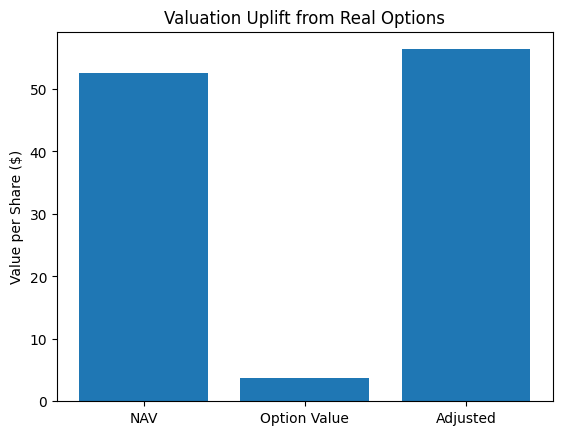

In [ ]:
# Graphing
labels = ['NAV', "Option Value", "Adjusted"]
values = [nav_per_share, option_value_per_share, nav_per_share + option_value_per_share]

plt.bar(labels, values)
plt.title("Valuation Uplift from Option")
plt.ylabel("Value per Share ($)")
plt.show()


## 6. Sensitivity

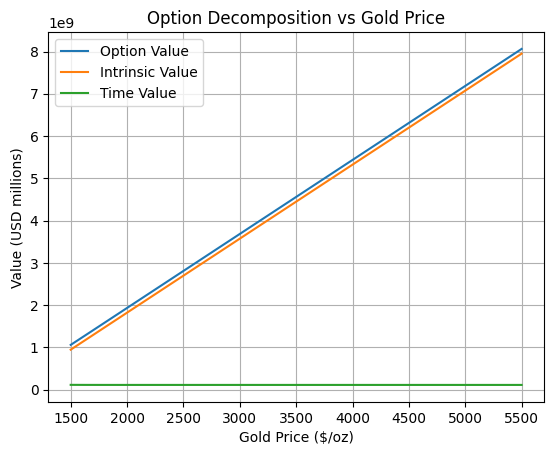

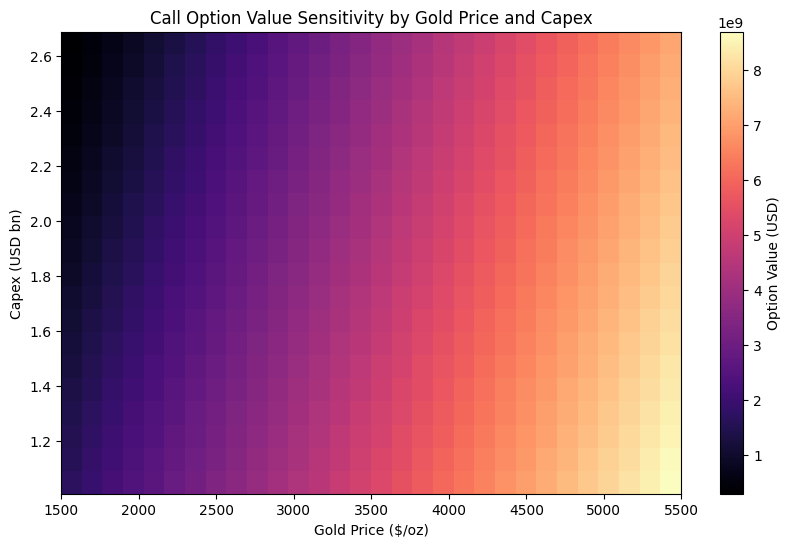

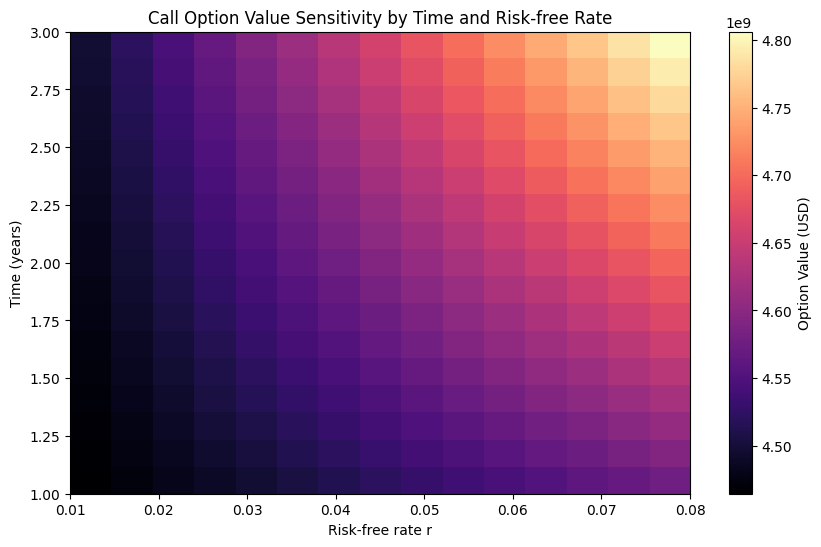

          Gold  Project Value (S)  Option Value (C)  Intrinsic (S-K)  \
0  1500.000000       2.626500e+09      1.058948e+09     9.456000e+08   
1  1637.931034       2.868017e+09      1.299324e+09     1.187117e+09   
2  1775.862069       3.109534e+09      1.540484e+09     1.428634e+09   
3  1913.793103       3.351052e+09      1.781893e+09     1.670152e+09   
4  2051.724138       3.592569e+09      2.023377e+09     1.911669e+09   

     Time Value  Option per Share  Time Value per Share  
0  1.133479e+08          0.867066              0.092809  
1  1.122064e+08          1.063886              0.091875  
2  1.118495e+08          1.261348              0.091582  
3  1.117409e+08          1.459013              0.091493  
4  1.117084e+08          1.656741              0.091467  


In [146]:
def scale_S(base_S, base_gold, gold_new):
    return base_S * (gold_new/base_gold)

# Preserve original project value as of base gold price and avoid mutating it in loops
base_S = S

# Scenario grid over Gold price (for baseline 1D diagnostics)
gold_prices = np.linspace(1500, 5500, 30)
results = []

for g in gold_prices:
    S_gold = scale_S(base_S, base_gold, g)
    C = black_scholes(S_gold, K, sigma, r, T)
    intrinsic = max(S_gold - K, 0)
    time_value = C - intrinsic

    results.append([g, S_gold, C, intrinsic, time_value])

df = pd.DataFrame(results, columns=[
    "Gold", "Project Value (S)", "Option Value (C)", "Intrinsic (S-K)", "Time Value"
])

# Per share values
df["Option per Share"] = df["Option Value (C)"] / shares_outstanding
df["Time Value per Share"] = df["Time Value"] / shares_outstanding


# ================================
# 5. Plot 1 — Core Insight
# ================================
plt.figure()
plt.plot(df["Gold"], df["Option Value (C)"], label="Option Value")
plt.plot(df["Gold"], df["Intrinsic (S-K)"], label="Intrinsic Value")
plt.plot(df["Gold"], df["Time Value"], label="Time Value")
plt.xlabel("Gold Price ($/oz)")
plt.ylabel("Value (USD millions)")
plt.title("Option Decomposition vs Gold Price")
plt.legend()
plt.grid()
plt.show()


# ================================
# 6. Sensitivity Heatmap (Gold x Capex)
# ================================
gold_grid = np.linspace(1500, 5500, 30)
capex_grid = np.linspace(0.6 * K, 1.6 * K, 20)
capex_grid_bn = capex_grid / 1e9

sensitivity_values = np.empty((len(capex_grid), len(gold_grid)))
for i, k_capex in enumerate(capex_grid):
    for j, g in enumerate(gold_grid):
        S_gold = scale_S(base_S, base_gold, g)
        sensitivity_values[i, j] = black_scholes(S_gold, k_capex, sigma, r, T)

sensitivity_table = pd.DataFrame(
    sensitivity_values,
    index=pd.Index(np.round(capex_grid_bn, 3), name="Capex (USD bn)"),
    columns=pd.Index(np.round(gold_grid, 0), name="Gold Price ($/oz)")
)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(
    sensitivity_table.values,
    origin="lower",
    aspect="auto",
    cmap="magma",
    extent=(gold_grid[0], gold_grid[-1], capex_grid_bn[0], capex_grid_bn[-1]),
)

ax.set_title("Call Option Value Sensitivity by Gold Price and Capex")
ax.set_xlabel("Gold Price ($/oz)")
ax.set_ylabel("Capex (USD bn)")

fig.colorbar(im, ax=ax, label="Option Value (USD)")
plt.show()

# Optional: inspect the exact sensitivity surface as a table
gold_capex_table = sensitivity_table
gold_capex_table


# ================================
# 7. Sensitivity Heatmap (T x r)
# ================================
time_grid = np.linspace(1.0, 3.0, 17)
rate_grid = np.linspace(0.01, 0.08, 15)

time_rate_values = np.empty((len(time_grid), len(rate_grid)))
for i, t in enumerate(time_grid):
    for j, rate in enumerate(rate_grid):
        time_rate_values[i, j] = black_scholes(base_S, K, sigma, rate, t)

time_rate_table = pd.DataFrame(
    time_rate_values,
    index=pd.Index(np.round(time_grid, 2), name="Time (years)"),
    columns=pd.Index(np.round(rate_grid, 4), name="Risk-free rate r")
)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(
    time_rate_table.values,
    origin="lower",
    aspect="auto",
    cmap="magma",
    extent=(rate_grid[0], rate_grid[-1], time_grid[0], time_grid[-1]),
)

ax.set_title("Call Option Value Sensitivity by Time and Risk-free Rate")
ax.set_xlabel("Risk-free rate r")
ax.set_ylabel("Time (years)")

fig.colorbar(im, ax=ax, label="Option Value (USD)")
plt.show()

# Optional: inspect time x rate surface as a table
time_rate_table


# ================================
# 8. Output Table (Preview)
# ================================
print(df.head())

